# Muhammad Bilal
# 22F-3309
# Deep Learning Assignment-04

# Long Short-Term Memory (LSTM) - Time Series Prediction
**Steps:**




*  Use a simple time series dataset (temperature or stock prices):
We will use a simple sine wave as a synthetic time series dataset for temperature prediction, but you can replace this with a real dataset like stock prices or temperature data later.
*   Build the LSTM model to predict the next value in the sequence.

*   Train the model and plot the training loss and predicted vs actual values

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.4706 - val_loss: 0.1700
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1339 - val_loss: 0.0918
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0932 - val_loss: 0.0756
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0712 - val_loss: 0.0703
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0650 - val_loss: 0.0638
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0592 - val_loss: 0.0580
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0586 - val_loss: 0.0514
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0490 - val_loss: 0.0439
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0404 - val_loss: 0.0334
Epoch 10/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0298 - val_loss: 0.0207
Epoch 11/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0173 - val_loss: 0.0078
Epoch 12/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0061 - val

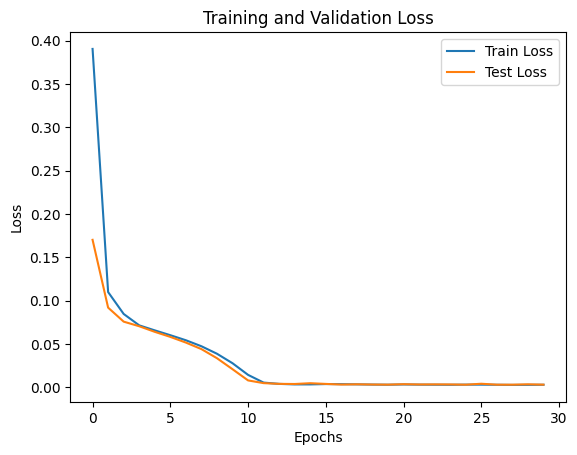

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


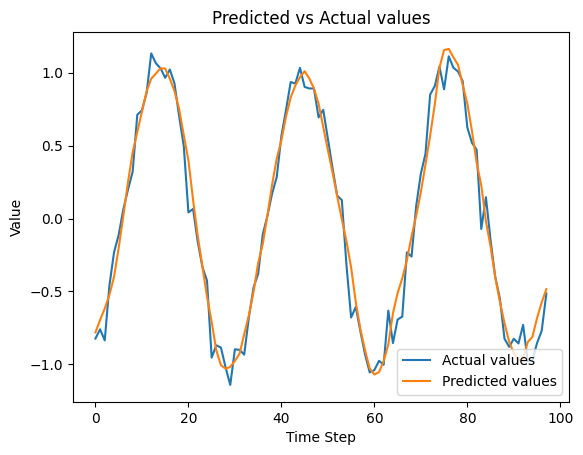

In [1]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Generating a simple sine wave time series (you can replace this with actual data)
np.random.seed(0)
time_steps = np.linspace(0, 100, 500)
data = np.sin(time_steps) + 0.1 * np.random.randn(500)  # sine wave with noise

# Reshaping the data for scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1))

# Prepare data for LSTM (creating sequences for time steps)
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 10  # using 10 previous time steps to predict the next value
X, y = create_dataset(data_scaled, time_step)

# Reshaping X to be suitable for LSTM input
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Building the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(time_step, 1)))
model.add(Dense(1))

# Compiling the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Training the model
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Plotting training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# Predicting the future values
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Rescale the predictions back to the original range
train_predict = scaler.inverse_transform(train_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plotting predicted vs actual values
plt.plot(y_test_actual, label='Actual values')
plt.plot(test_predict, label='Predicted values')
plt.legend()
plt.title('Predicted vs Actual values')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.show()


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 982ms/step - loss: 0.6723
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.6198
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5691
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.5203
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4734
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4282
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3849
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3436
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3045
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2677
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.2338
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2032
Epoch 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1765
Epoch 14/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1545
Epoch 15/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1380
Epoch 16/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms

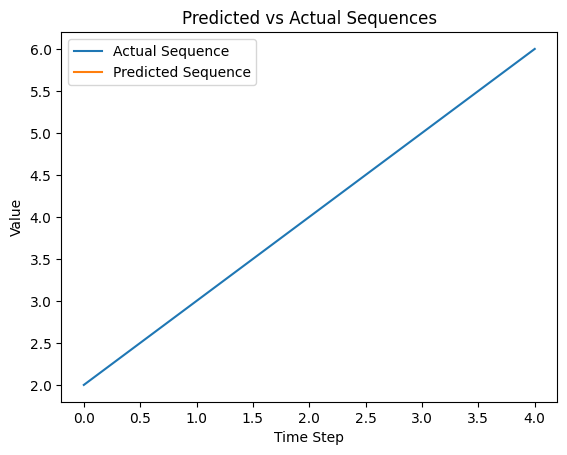

In [3]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# Data Generation (input and target sequences)
input_sequence = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Input sequence [1, 2, 3, 4, 5]
target_sequence = np.array([2, 3, 4, 5, 6]).reshape(-1, 1)  # Target sequence [2, 3, 4, 5, 6]

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
input_sequence_scaled = scaler.fit_transform(input_sequence)
target_sequence_scaled = scaler.transform(target_sequence)

# Reshaping data for LSTM (Encoder-Decoder model requires 3D input)
X = input_sequence_scaled.reshape((1, len(input_sequence), 1))  # Shape: (1, 5, 1)
y = target_sequence_scaled.reshape((1, len(target_sequence), 1))  # Shape: (1, 5, 1)

# Building the Encoder-Decoder Model
model = Sequential()
model.add(LSTM(128, input_shape=(X.shape[1], X.shape[2]), return_sequences=False))
model.add(Dense(1))

# Compiling the model
model.compile(optimizer=Adam(), loss='mean_squared_error')

# Training the model
model.fit(X, y, epochs=30, batch_size=1)

# Predicting the output
predicted_output = model.predict(X)

# Inverse scaling to get actual values
predicted_output_rescaled = scaler.inverse_transform(predicted_output)
target_sequence_rescaled = scaler.inverse_transform(target_sequence_scaled)

# Plotting Predicted vs Actual sequences
plt.plot(target_sequence_rescaled, label='Actual Sequence')
plt.plot(predicted_output_rescaled, label='Predicted Sequence')
plt.legend()
plt.title('Predicted vs Actual Sequences')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.show()

